## ⚙️ **Libraries Import**

In [52]:
# Set seed for reproducibility
SEED = 45

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
# from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Check if MPS is available and set it as the device
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Metal) backend!")
else:
    device = torch.device("cpu")
    print("MPS not available, using CPU.")

# Import other libraries
import copy
import shutil
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

/Users/andreamastroberti/.zshenv:.:1: no such file or directory: /Users/andreamastroberti/.cargo/env
The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
/Users/andreamastroberti/.zshenv:.:1: no such file or directory: /Users/andreamastroberti/.cargo/env
PyTorch version: 2.8.0
Device: cpu
Using MPS (Apple Metal) backend!


In [53]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/the-pirate-pain-dataset'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## ⏳ **Data Loading**

In [54]:
os.environ["DATASETS"] = "."
os.environ["DATASET_train"] = "./data/pirate_pain_train.csv"
os.environ["DATASET_test"] = "./data/pirate_pain_test.csv"
os.environ["DATASET_train-labels"] = "./data/pirate_pain_train_labels.csv"

## 🔎 **Exploration and Data Analysis**

In [55]:
# Load the dataset from a CSV file
df_train = pd.read_csv(os.environ["DATASET_train"])
df_public_test = pd.read_csv(os.environ["DATASET_test"])
df_labels = pd.read_csv(os.environ["DATASET_train-labels"])
# df_public_test['sample_index'].unique()

In [56]:
from sklearn.model_selection import train_test_split

# Aggregate labels per user
user_labels = df_labels.copy()  # assuming df_labels has 'sample_index' and 'label_idx'

# Split users into train and val, stratified by label
train_users, val_users = train_test_split(
    user_labels['sample_index'],
    test_size=0.2,              # 20% validation
    stratify=user_labels['label'],
    random_state=SEED
)

# Select rows for train and validation
df_train_fold = df_train[df_train['sample_index'].isin(train_users)]
df_val_fold   = df_train[df_train['sample_index'].isin(val_users)]
# Merge labels into the training dataframe
df_train_fold = df_train_fold.merge(df_labels, on='sample_index', how='left')
df_val_fold = df_val_fold.merge(df_labels, on='sample_index', how='left')

# Check class distribution
print(df_train_fold['label'].value_counts(normalize=True))
print(df_val_fold['label'].value_counts(normalize=True))

df_train = df_train_fold.copy()
df_train = df_train.drop('label', axis=1)
df_val = df_val_fold.copy()
df_val = df_val.drop('label', axis=1)


label
no_pain      0.772727
low_pain     0.142045
high_pain    0.085227
Name: proportion, dtype: float64
label
no_pain      0.774436
low_pain     0.142857
high_pain    0.082707
Name: proportion, dtype: float64


In [57]:
# Display the first 10 rows of the DataFrame
# Display a summary of the dataset's structure and data types
df_train.info()
df_train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84480 entries, 0 to 84479
Data columns (total 40 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sample_index   84480 non-null  int64  
 1   time           84480 non-null  int64  
 2   pain_survey_1  84480 non-null  int64  
 3   pain_survey_2  84480 non-null  int64  
 4   pain_survey_3  84480 non-null  int64  
 5   pain_survey_4  84480 non-null  int64  
 6   n_legs         84480 non-null  object 
 7   n_hands        84480 non-null  object 
 8   n_eyes         84480 non-null  object 
 9   joint_00       84480 non-null  float64
 10  joint_01       84480 non-null  float64
 11  joint_02       84480 non-null  float64
 12  joint_03       84480 non-null  float64
 13  joint_04       84480 non-null  float64
 14  joint_05       84480 non-null  float64
 15  joint_06       84480 non-null  float64
 16  joint_07       84480 non-null  float64
 17  joint_08       84480 non-null  float64
 18  joint_

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
0,0,0,2,0,2,1,two,two,two,1.094705,...,3.499558e-06,1.945042e-06,0.000004,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5
1,0,1,2,2,2,2,two,two,two,1.135183,...,3.976952e-07,6.765107e-07,0.000006,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5
2,0,2,2,0,2,2,two,two,two,1.080745,...,1.533820e-07,1.698525e-07,0.000001,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5
3,0,3,2,2,2,2,two,two,two,0.938017,...,1.006865e-05,5.511079e-07,0.000002,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5
4,0,4,2,2,2,2,two,two,two,1.090185,...,4.437266e-06,1.735459e-07,0.000002,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5


## 🔄 **Data Preprocessing**

In [ ]:
# Map int64, float64, string to float32
mapping = {
    "one+peg_leg": 1,
    "one+hook_hand": 1,
    "one+eye_patch": 1,
    "two": 2,
}

# Train data
for col in df_train:
    if df_train[col].dtype == 'int64' and col not in ['sample_index', 'time']:
        df_train[col] = df_train[col].astype(np.float32)
    elif df_train[col].dtype == 'float64':
        df_train[col] = df_train[col].astype(np.float32)
    elif df_train[col].dtype == 'object':
        df_train[col] = df_train[col].replace(mapping)
        df_train[col] = df_train[col].astype(np.float32)

#Validation data
for col in df_val:
    if df_val[col].dtype == 'int64' and col not in ['sample_index', 'time']:
        df_val[col] = df_val[col].astype(np.float32)
    elif df_val[col].dtype == 'float64':
        df_val[col] = df_val[col].astype(np.float32)
    elif df_val[col].dtype == 'object':
        df_val[col] = df_val[col].replace(mapping)
        df_val[col] = df_val[col].astype(np.float32)
        
#Public test data
for col in df_public_test:
    if df_public_test[col].dtype == 'int64' and col not in ['sample_index', 'time']:
        df_public_test[col] = df_public_test[col].astype(np.float32)
    elif df_public_test[col].dtype == 'float64':
        df_public_test[col] = df_public_test[col].astype(np.float32)
    elif df_public_test[col].dtype == 'object':
        df_public_test[col] = df_public_test[col].replace(mapping)
        df_public_test[col] = df_public_test[col].astype(np.float32)

In [ ]:
# MAP labels
label_mapping = {label: idx for idx, label in enumerate(df_labels['label'].unique())}
df_labels['label_idx'] = df_labels['label'].map(label_mapping)
df_labels.drop('label', axis=1, inplace=True)
df_labels.head()

,sample_index,label_idx
0,0,0
1,1,0
2,2,1
3,3,0
4,4,0


In [ ]:
df_train.info()
df_train.head()

In [ ]:
from sklearn.preprocessing import StandardScaler

# Columns to scale
# scale_columns = ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4', 'n_legs', 'n_hands', 'n_eyes'] + [f'joint_{i:02d}' for i in range(0, 31)]
scale_columns = ['n_legs', 'n_hands', 'n_eyes'] + [f'joint_{i:02d}' for i in range(0, 31)]

# Initialize scaler
scaler = StandardScaler()

# Fit scaler only on training data
scaler.fit(df_train[scale_columns])

# Transform train, val, test, public_test
df_train[scale_columns] = scaler.transform(df_train[scale_columns])
df_val[scale_columns]   = scaler.transform(df_val[scale_columns])
df_public_test[scale_columns] = scaler.transform(df_public_test[scale_columns])

In [ ]:
# Display the first five rows of the training DataFrame
print(df_train.shape)
df_train.head()

(84480, 40)


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
0,0,0,2.0,0.0,2.0,1.0,0.107211,0.107211,0.107211,0.722303,...,-0.007833,-0.007880,-0.025838,-0.052646,-0.029761,-0.418274,-0.576429,-0.395159,-0.486506,0.0
1,0,1,2.0,2.0,2.0,2.0,0.107211,0.107211,0.107211,0.916288,...,-0.008391,-0.008087,-0.024374,-0.081773,-0.030827,-0.491816,-0.749838,-0.611475,-0.677598,0.0
2,0,2,2.0,0.0,2.0,2.0,0.107211,0.107211,0.107211,0.655399,...,-0.008434,-0.008170,-0.027689,-0.075743,-0.030123,-0.441979,-0.645719,-0.438688,-0.550339,0.0
3,0,3,2.0,2.0,2.0,2.0,0.107211,0.107211,0.107211,-0.028610,...,-0.006653,-0.008108,-0.027398,-0.081753,-0.030827,-0.518193,-0.654196,-0.365897,-0.529423,0.0
4,0,4,2.0,2.0,2.0,2.0,0.107211,0.107211,0.107211,0.700640,...,-0.007665,-0.008169,-0.027612,-0.081743,-0.028855,-0.630437,-0.717339,-0.294770,-0.520209,0.0


In [ ]:
# Define the window size
WINDOW_SIZE = 20

# Define the stride for overlapping
STRIDE = 5

In [ ]:
# List of feature columns
exclude = ["sample_index", "time", 'n_legs', 'n_hands', 'n_eyes']
feature_cols = [col for col in df_train.columns if col not in exclude]

In [ ]:
def build_sequences(df, df_labels, window, stride):
    """
    Build sliding window sequences WITH padding for the Pirate Pain dataset.

    Parameters
    ----------
    df : DataFrame
        Feature data (contains sample_index, time, and feature columns)
    df_labels : DataFrame
        Label data (sample_index, label_idx)
    window : int
        Number of timesteps per sequence
    stride : int
        Step between windows (controls overlap)

    Returns
    -------
    X : np.array   shape = (num_sequences, window, num_features)
    y : np.array   shape = (num_sequences,)
    """

    assert window % stride == 0, "window must be divisible by stride"

    X = []
    y = []

    for sid in df["sample_index"].unique():

        # Extract joint-related features per sequence
        temp = df[df["sample_index"] == sid][feature_cols].values.astype("float32")

        # Get label
        label = df_labels.loc[df_labels["sample_index"] == sid, "label_idx"].iloc[0]

        # --- Padding section ---
        remainder = len(temp) % window
        if remainder > 0:
            pad_len = window - remainder
            padding = np.zeros((pad_len, temp.shape[1]), dtype="float32")
            temp = np.concatenate((temp, padding), axis=0)

        # Build sliding windows
        idx = 0
        while idx + window <= len(temp):
            X.append(temp[idx:idx + window])
            y.append(label)
            idx += stride

    return np.array(X), np.array(y)


In [ ]:
# Generate sequences and labels
X_train, y_train = build_sequences(df_train, df_labels, WINDOW_SIZE, STRIDE)
X_val,   y_val   = build_sequences(df_val,   df_labels,   WINDOW_SIZE, STRIDE)
# X_test,  y_test  = build_sequences(df_test,  df_labels,  WINDOW_SIZE, STRIDE)

X_train.shape, y_train.shape, X_val.shape, y_val.shape

((15312, 20, 35), (15312,), (3857, 20, 35), (3857,))

In [ ]:
# Define the input shape based on the training data
input_shape = X_train.shape[1:]

# Define the number of classes based on the categorical labels
num_classes = len(np.unique(y_train))

In [ ]:
# Convert numpy arrays to PyTorch datasets (pairs features with labels)
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
# test_ds  = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

In [ ]:
# Define the batch size, which is the number of samples in each batch
BATCH_SIZE = 64

In [ ]:
def make_loader(ds, batch_size, shuffle, drop_last):
    # Determine optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,  # Faster GPU transfer
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,  # Load 4 batches ahead
    )

In [ ]:
# Create data loaders with different settings for each phase
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
# test_loader  = make_loader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [ ]:
# Get one batch from the training data loader
for xb, yb in train_loader:
    print("Features batch shape:", xb.shape)
    print("Labels batch shape:", yb.shape)
    break # Stop after getting one batch

Features batch shape: torch.Size([64, 20, 35])
Labels batch shape: torch.Size([64])


## 🛠️ **Model Building**

In [ ]:
def recurrent_summary(model, input_size):
    """
    Custom summary function that emulates torchinfo's output while correctly
    counting parameters for RNN/GRU/LSTM layers.

    This function is designed for models whose direct children are
    nn.Linear, nn.RNN, nn.GRU, or nn.LSTM layers.

    Args:
        model (nn.Module): The model to analyze.
        input_size (tuple): Shape of the input tensor (e.g., (seq_len, features)).
    """

    # Dictionary to store output shapes captured by forward hooks
    output_shapes = {}
    # List to track hook handles for later removal
    hooks = []

    def get_hook(name):
        """Factory function to create a forward hook for a specific module."""
        def hook(module, input, output):
            # Handle RNN layer outputs (returns a tuple)
            if isinstance(output, tuple):
                # output[0]: all hidden states with shape (batch, seq_len, hidden*directions)
                shape1 = list(output[0].shape)
                shape1[0] = -1  # Replace batch dimension with -1

                # output[1]: final hidden state h_n (or tuple (h_n, c_n) for LSTM)
                if isinstance(output[1], tuple):  # LSTM case: (h_n, c_n)
                    shape2 = list(output[1][0].shape)  # Extract h_n only
                else:  # RNN/GRU case: h_n only
                    shape2 = list(output[1].shape)

                # Replace batch dimension (middle position) with -1
                shape2[1] = -1

                output_shapes[name] = f"[{shape1}, {shape2}]"

            # Handle standard layer outputs (e.g., Linear)
            else:
                shape = list(output.shape)
                shape[0] = -1  # Replace batch dimension with -1
                output_shapes[name] = f"{shape}"
        return hook

    # 1. Determine the device where model parameters reside
    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = torch.device("cpu")  # Fallback for models without parameters

    # 2. Create a dummy input tensor with batch_size=1
    dummy_input = torch.randn(1, *input_size).to(device)

    # 3. Register forward hooks on target layers
    # Iterate through direct children of the model (e.g., self.rnn, self.classifier)
    for name, module in model.named_children():
        if isinstance(module, (nn.Linear, nn.RNN, nn.GRU, nn.LSTM)):
            # Register the hook and store its handle for cleanup
            hook_handle = module.register_forward_hook(get_hook(name))
            hooks.append(hook_handle)

    # 4. Execute a dummy forward pass in evaluation mode
    model.eval()
    with torch.no_grad():
        try:
            model(dummy_input)
        except Exception as e:
            print(f"Error during dummy forward pass: {e}")
            # Clean up hooks even if an error occurs
            for h in hooks:
                h.remove()
            return

    # 5. Remove all registered hooks
    for h in hooks:
        h.remove()

    # --- 6. Print the summary table ---

    print("-" * 79)
    # Column headers
    print(f"{'Layer (type)':<25} {'Output Shape':<28} {'Param #':<18}")
    print("=" * 79)

    total_params = 0
    total_trainable_params = 0

    # Iterate through modules again to collect and display parameter information
    for name, module in model.named_children():
        if name in output_shapes:
            # Count total and trainable parameters for this module
            module_params = sum(p.numel() for p in module.parameters())
            trainable_params = sum(p.numel() for p in module.parameters() if p.requires_grad)

            total_params += module_params
            total_trainable_params += trainable_params

            # Format strings for display
            layer_name = f"{name} ({type(module).__name__})"
            output_shape_str = str(output_shapes[name])
            params_str = f"{trainable_params:,}"

            print(f"{layer_name:<25} {output_shape_str:<28} {params_str:<15}")

    print("=" * 79)
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {total_trainable_params:,}")
    print(f"Non-trainable params: {total_params - total_trainable_params:,}")
    print("-" * 79)

In [ ]:
class RecurrentClassifier(nn.Module):
    """
    Generic RNN classifier (RNN, LSTM, GRU).
    Uses the last hidden state for classification.
    """
    def __init__(
            self,
            input_size,
            hidden_size,
            num_layers,
            num_classes,
            rnn_type='GRU',        # 'RNN', 'LSTM', or 'GRU'
            bidirectional=False,
            dropout_rate=0.2
            ):
        super().__init__()

        self.rnn_type = rnn_type
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional

        # Map string name to PyTorch RNN class
        rnn_map = {
            'RNN': nn.RNN,
            'LSTM': nn.LSTM,
            'GRU': nn.GRU
        }

        if rnn_type not in rnn_map:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")

        rnn_module = rnn_map[rnn_type]

        # Dropout is only applied between layers (if num_layers > 1)
        dropout_val = dropout_rate if num_layers > 1 else 0

        # Create the recurrent layer
        self.rnn = rnn_module(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,       # Input shape: (batch, seq_len, features)
            bidirectional=bidirectional,
            dropout=dropout_val
        )

        # Calculate input size for the final classifier
        if self.bidirectional:
            classifier_input_size = hidden_size * 2 # Concat fwd + bwd
        else:
            classifier_input_size = hidden_size

        # Final classification layer
        self.classifier = nn.Linear(classifier_input_size, num_classes)

    def forward(self, x):
        """
        x shape: (batch_size, seq_length, input_size)
        """

        # rnn_out shape: (batch_size, seq_len, hidden_size * num_directions)
        rnn_out, hidden = self.rnn(x)

        # LSTM returns (h_n, c_n), we only need h_n
        if self.rnn_type == 'LSTM':
            hidden = hidden[0]

        # hidden shape: (num_layers * num_directions, batch_size, hidden_size)

        if self.bidirectional:
            # Reshape to (num_layers, 2, batch_size, hidden_size)
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_size)

            # Concat last fwd (hidden[-1, 0, ...]) and bwd (hidden[-1, 1, ...])
            # Final shape: (batch_size, hidden_size * 2)
            hidden_to_classify = torch.cat([hidden[-1, 0, :, :], hidden[-1, 1, :, :]], dim=1)
        else:
            # Take the last layer's hidden state
            # Final shape: (batch_size, hidden_size)
            hidden_to_classify = hidden[-1]

        # Get logits
        logits = self.classifier(hidden_to_classify)
        return logits


# # Create model and display architecture with parameter count
# rnn_model = RecurrentClassifier(
#     input_size=input_shape[-1], # Pass the number of features
#     hidden_size=128,
#     num_layers=2,
#     num_classes=num_classes,
#     dropout_rate=0.,
#     rnn_type='RNN'
#     ).to(device)
# recurrent_summary(rnn_model, input_size=input_shape)

## 📚 **Handling Static Features in Recurrent Models**

Static features (like `n_legs`, `n_hands`, `n_eyes`) are constant per sample but can be highly informative.
Here are several approaches to incorporate them into recurrent models:

### **Approach 1: Concatenate to Each Timestep** (Simplest)
- Concatenate static features to the temporal features at each timestep
- Pros: Simple, easy to implement
- Cons: Redundant (same values repeated), may not be optimal

### **Approach 2: Separate Branch Architecture** (Recommended)
- Process static features through a separate MLP branch
- Process temporal features through LSTM
- Concatenate outputs before final classification
- Pros: More efficient, better representation learning
- Cons: Slightly more complex

### **Approach 3: Initialize Hidden State**
- Use static features to initialize LSTM hidden/cell states
- Pros: Encodes static info into the recurrent dynamics
- Cons: May be harder to train, less flexible

### **Approach 4: Hybrid Approach**
- Combine multiple methods (e.g., separate branch + concatenate at end)
- Pros: Most flexible, can capture different interactions
- Cons: More parameters, risk of overfitting

**Note**: Based on your EDA, static features (`n_legs`, `n_hands`, `n_eyes`) are highly discriminative,
especially for `high_pain` class. Including them should improve model performance!


### **Approach 1: Concatenate Static Features to Each Timestep**


In [ ]:
class RecurrentClassifierWithStaticConcatenated(nn.Module):
    """
    LSTM classifier that concatenates static features to each timestep.
    Simple but effective approach.
    """
    def __init__(
            self,
            temporal_input_size,    # Size of temporal features (e.g., joint features)
            static_input_size,      # Size of static features (e.g., n_legs, n_hands, n_eyes)
            hidden_size,
            num_layers,
            num_classes,
            rnn_type='LSTM',
            bidirectional=False,
            dropout_rate=0.2
            ):
        super().__init__()

        self.rnn_type = rnn_type
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional

        # Map string name to PyTorch RNN class
        rnn_map = {
            'RNN': nn.RNN,
            'LSTM': nn.LSTM,
            'GRU': nn.GRU
        }

        if rnn_type not in rnn_map:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")

        rnn_module = rnn_map[rnn_type]

        # Combined input size (temporal + static)
        combined_input_size = temporal_input_size + static_input_size

        # Dropout is only applied between layers (if num_layers > 1)
        dropout_val = dropout_rate if num_layers > 1 else 0

        # Create the recurrent layer with combined input
        self.rnn = rnn_module(
            input_size=combined_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout_val
        )

        # Calculate input size for the final classifier
        if self.bidirectional:
            classifier_input_size = hidden_size * 2
        else:
            classifier_input_size = hidden_size

        # Final classification layer
        self.classifier = nn.Linear(classifier_input_size, num_classes)

    def forward(self, x_temporal, x_static):
        """
        x_temporal: (batch_size, seq_length, temporal_input_size)
        x_static: (batch_size, static_input_size) - will be repeated for each timestep
        """
        batch_size, seq_len, _ = x_temporal.shape

        # Repeat static features for each timestep
        # x_static: (batch_size, static_input_size) -> (batch_size, seq_len, static_input_size)
        x_static_expanded = x_static.unsqueeze(1).expand(-1, seq_len, -1)

        # Concatenate temporal and static features
        # Result: (batch_size, seq_len, temporal_input_size + static_input_size)
        x_combined = torch.cat([x_temporal, x_static_expanded], dim=2)

        # Pass through RNN
        rnn_out, hidden = self.rnn(x_combined)

        # Extract last hidden state
        if self.rnn_type == 'LSTM':
            hidden = hidden[0]  # LSTM returns (h_n, c_n)

        if self.bidirectional:
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_size)
            hidden_to_classify = torch.cat([hidden[-1, 0, :, :], hidden[-1, 1, :, :]], dim=1)
        else:
            hidden_to_classify = hidden[-1]

        # Get logits
        logits = self.classifier(hidden_to_classify)
        return logits


### **Approach 2: Separate Branch Architecture** (Recommended)


In [ ]:
class RecurrentClassifierWithStaticBranch(nn.Module):
    """
    LSTM classifier with separate branch for static features.
    This is the recommended approach as it's more efficient and allows
    better representation learning for static vs temporal features.
    """
    def __init__(
            self,
            temporal_input_size,    # Size of temporal features
            static_input_size,      # Size of static features
            hidden_size,
            num_layers,
            num_classes,
            static_hidden_sizes=[32, 16],  # MLP layers for static features
            rnn_type='LSTM',
            bidirectional=False,
            dropout_rate=0.2
            ):
        super().__init__()

        self.rnn_type = rnn_type
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional

        # Map string name to PyTorch RNN class
        rnn_map = {
            'RNN': nn.RNN,
            'LSTM': nn.LSTM,
            'GRU': nn.GRU
        }

        if rnn_type not in rnn_map:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")

        rnn_module = rnn_map[rnn_type]

        # Dropout for RNN (only between layers if num_layers > 1)
        dropout_val = dropout_rate if num_layers > 1 else 0

        # Recurrent layer for temporal features
        self.rnn = rnn_module(
            input_size=temporal_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout_val
        )

        # MLP branch for static features
        static_layers = []
        input_size = static_input_size
        for hidden_size_static in static_hidden_sizes:
            static_layers.append(nn.Linear(input_size, hidden_size_static))
            static_layers.append(nn.ReLU())
            static_layers.append(nn.Dropout(dropout_rate))
            input_size = hidden_size_static
        self.static_branch = nn.Sequential(*static_layers)
        static_output_size = static_hidden_sizes[-1]

        # Calculate input size for the final classifier
        if self.bidirectional:
            rnn_output_size = hidden_size * 2
        else:
            rnn_output_size = hidden_size

        # Final classification layer (combines RNN output + static branch output)
        classifier_input_size = rnn_output_size + static_output_size
        self.classifier = nn.Linear(classifier_input_size, num_classes)

    def forward(self, x_temporal, x_static):
        """
        x_temporal: (batch_size, seq_length, temporal_input_size)
        x_static: (batch_size, static_input_size)
        """
        # Process temporal features through RNN
        rnn_out, hidden = self.rnn(x_temporal)

        # Extract last hidden state
        if self.rnn_type == 'LSTM':
            hidden = hidden[0]

        if self.bidirectional:
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_size)
            rnn_output = torch.cat([hidden[-1, 0, :, :], hidden[-1, 1, :, :]], dim=1)
        else:
            rnn_output = hidden[-1]  # (batch_size, hidden_size)

        # Process static features through MLP branch
        static_output = self.static_branch(x_static)  # (batch_size, static_hidden_sizes[-1])

        # Concatenate RNN output and static branch output
        combined = torch.cat([rnn_output, static_output], dim=1)  # (batch_size, rnn_output_size + static_output_size)

        # Get logits
        logits = self.classifier(combined)
        return logits


### **Approach 3: Initialize Hidden State with Static Features**


In [ ]:
class RecurrentClassifierWithStaticInitialization(nn.Module):
    """
    LSTM classifier that uses static features to initialize hidden/cell states.
    This encodes static information into the recurrent dynamics.
    """
    def __init__(
            self,
            temporal_input_size,
            static_input_size,
            hidden_size,
            num_layers,
            num_classes,
            rnn_type='LSTM',
            bidirectional=False,
            dropout_rate=0.2
            ):
        super().__init__()

        self.rnn_type = rnn_type
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional
        num_directions = 2 if bidirectional else 1

        # Map string name to PyTorch RNN class
        rnn_map = {
            'RNN': nn.RNN,
            'LSTM': nn.LSTM,
            'GRU': nn.GRU
        }

        if rnn_type not in rnn_map:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")

        rnn_module = rnn_map[rnn_type]

        # Dropout for RNN
        dropout_val = dropout_rate if num_layers > 1 else 0

        # Recurrent layer
        self.rnn = rnn_module(
            input_size=temporal_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout_val
        )

        # MLP to generate initial hidden state from static features
        # For LSTM, we need both h_0 and c_0
        if rnn_type == 'LSTM':
            # Need to generate both hidden and cell states
            self.hidden_init = nn.Sequential(
                nn.Linear(static_input_size, hidden_size * num_layers * num_directions),
                nn.Tanh()
            )
            self.cell_init = nn.Sequential(
                nn.Linear(static_input_size, hidden_size * num_layers * num_directions),
                nn.Tanh()
            )
        else:
            # For RNN/GRU, only need hidden state
            self.hidden_init = nn.Sequential(
                nn.Linear(static_input_size, hidden_size * num_layers * num_directions),
                nn.Tanh()
            )

        # Calculate input size for the final classifier
        if self.bidirectional:
            classifier_input_size = hidden_size * 2
        else:
            classifier_input_size = hidden_size

        # Final classification layer
        self.classifier = nn.Linear(classifier_input_size, num_classes)

    def forward(self, x_temporal, x_static):
        """
        x_temporal: (batch_size, seq_length, temporal_input_size)
        x_static: (batch_size, static_input_size)
        """
        batch_size = x_temporal.size(0)

        # Generate initial hidden state from static features
        if self.rnn_type == 'LSTM':
            h_0 = self.hidden_init(x_static)  # (batch_size, hidden_size * num_layers * num_directions)
            c_0 = self.cell_init(x_static)    # (batch_size, hidden_size * num_layers * num_directions)
            
            # Reshape to (num_layers * num_directions, batch_size, hidden_size)
            h_0 = h_0.view(self.num_layers * (2 if self.bidirectional else 1), batch_size, self.hidden_size)
            c_0 = c_0.view(self.num_layers * (2 if self.bidirectional else 1), batch_size, self.hidden_size)
            
            hidden = (h_0, c_0)
        else:
            h_0 = self.hidden_init(x_static)
            h_0 = h_0.view(self.num_layers * (2 if self.bidirectional else 1), batch_size, self.hidden_size)
            hidden = h_0

        # Pass through RNN with initialized hidden state
        rnn_out, hidden = self.rnn(x_temporal, hidden)

        # Extract last hidden state
        if self.rnn_type == 'LSTM':
            hidden = hidden[0]

        if self.bidirectional:
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_size)
            hidden_to_classify = torch.cat([hidden[-1, 0, :, :], hidden[-1, 1, :, :]], dim=1)
        else:
            hidden_to_classify = hidden[-1]

        # Get logits
        logits = self.classifier(hidden_to_classify)
        return logits


### **Approach 4: Hybrid Approach** (Combine Separate Branch + Hidden State Initialization)


In [ ]:
class RecurrentClassifierHybrid(nn.Module):
    """
    Hybrid approach: Combine static branch (Approach 2) with hidden state initialization (Approach 3).
    This gives the model maximum flexibility to use static features in multiple ways.
    """
    def __init__(
            self,
            temporal_input_size,
            static_input_size,
            hidden_size,
            num_layers,
            num_classes,
            static_hidden_sizes=[32, 16],
            rnn_type='LSTM',
            bidirectional=False,
            dropout_rate=0.2,
            use_static_init=True,      # Whether to use static features for initialization
            use_static_branch=True     # Whether to use separate static branch
            ):
        super().__init__()

        self.rnn_type = rnn_type
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional
        self.use_static_init = use_static_init
        self.use_static_branch = use_static_branch
        num_directions = 2 if bidirectional else 1

        # Map string name to PyTorch RNN class
        rnn_map = {
            'RNN': nn.RNN,
            'LSTM': nn.LSTM,
            'GRU': nn.GRU
        }

        if rnn_type not in rnn_map:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")

        rnn_module = rnn_map[rnn_type]

        # Dropout for RNN
        dropout_val = dropout_rate if num_layers > 1 else 0

        # Recurrent layer
        self.rnn = rnn_module(
            input_size=temporal_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout_val
        )

        # Static feature initialization (if enabled)
        if use_static_init:
            if rnn_type == 'LSTM':
                self.hidden_init = nn.Sequential(
                    nn.Linear(static_input_size, hidden_size * num_layers * num_directions),
                    nn.Tanh()
                )
                self.cell_init = nn.Sequential(
                    nn.Linear(static_input_size, hidden_size * num_layers * num_directions),
                    nn.Tanh()
                )
            else:
                self.hidden_init = nn.Sequential(
                    nn.Linear(static_input_size, hidden_size * num_layers * num_directions),
                    nn.Tanh()
                )

        # Static branch (if enabled)
        if use_static_branch:
            static_layers = []
            input_size = static_input_size
            for hidden_size_static in static_hidden_sizes:
                static_layers.append(nn.Linear(input_size, hidden_size_static))
                static_layers.append(nn.ReLU())
                static_layers.append(nn.Dropout(dropout_rate))
                input_size = hidden_size_static
            self.static_branch = nn.Sequential(*static_layers)
            static_output_size = static_hidden_sizes[-1]
        else:
            static_output_size = 0

        # Calculate input size for the final classifier
        if self.bidirectional:
            rnn_output_size = hidden_size * 2
        else:
            rnn_output_size = hidden_size

        # Final classification layer
        classifier_input_size = rnn_output_size + static_output_size
        self.classifier = nn.Linear(classifier_input_size, num_classes)

    def forward(self, x_temporal, x_static):
        """
        x_temporal: (batch_size, seq_length, temporal_input_size)
        x_static: (batch_size, static_input_size)
        """
        batch_size = x_temporal.size(0)

        # Initialize hidden state from static features (if enabled)
        if self.use_static_init:
            if self.rnn_type == 'LSTM':
                h_0 = self.hidden_init(x_static)
                c_0 = self.cell_init(x_static)
                h_0 = h_0.view(self.num_layers * (2 if self.bidirectional else 1), batch_size, self.hidden_size)
                c_0 = c_0.view(self.num_layers * (2 if self.bidirectional else 1), batch_size, self.hidden_size)
                hidden = (h_0, c_0)
            else:
                h_0 = self.hidden_init(x_static)
                h_0 = h_0.view(self.num_layers * (2 if self.bidirectional else 1), batch_size, self.hidden_size)
                hidden = h_0
        else:
            hidden = None  # Use default initialization

        # Process temporal features through RNN
        rnn_out, hidden = self.rnn(x_temporal, hidden)

        # Extract last hidden state
        if self.rnn_type == 'LSTM':
            hidden = hidden[0]

        if self.bidirectional:
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_size)
            rnn_output = torch.cat([hidden[-1, 0, :, :], hidden[-1, 1, :, :]], dim=1)
        else:
            rnn_output = hidden[-1]

        # Process static features through MLP branch (if enabled)
        if self.use_static_branch:
            static_output = self.static_branch(x_static)
            combined = torch.cat([rnn_output, static_output], dim=1)
        else:
            combined = rnn_output

        # Get logits
        logits = self.classifier(combined)
        return logits


### **Example: Modified Data Loading for Static Features**

To use the models above, you need to modify your data loading to separate temporal and static features.


In [ ]:
def build_sequences_with_static(df, df_labels, window, stride, temporal_cols, static_cols):
    """
    Build sliding window sequences WITH static features separated.
    
    Parameters
    ----------
    df : DataFrame
        Feature data (contains sample_index, time, and feature columns)
    df_labels : DataFrame
        Label data (sample_index, label_idx)
    window : int
        Number of timesteps per sequence
    stride : int
        Step between windows (controls overlap)
    temporal_cols : list
        List of temporal feature column names (e.g., joint features)
    static_cols : list
        List of static feature column names (e.g., n_legs, n_hands, n_eyes)
    
    Returns
    -------
    X_temporal : np.array   shape = (num_sequences, window, num_temporal_features)
    X_static : np.array     shape = (num_sequences, num_static_features)
    y : np.array            shape = (num_sequences,)
    """
    
    assert window % stride == 0, "window must be divisible by stride"
    
    X_temporal = []
    X_static = []
    y = []
    
    for sid in df["sample_index"].unique():
        # Extract temporal features per sequence
        temp_temporal = df[df["sample_index"] == sid][temporal_cols].values.astype("float32")
        
        # Check and handle NaN values in temporal features
        if np.isnan(temp_temporal).any():
            # Forward fill, then backward fill, then fill remaining with 0
            temp_df = pd.DataFrame(temp_temporal, columns=temporal_cols)
            temp_df = temp_df.ffill().bfill().fillna(0)
            temp_temporal = temp_df.values.astype("float32")
        
        # Extract static features (same for all timesteps, take first row)
        temp_static = df[df["sample_index"] == sid][static_cols].values[0].astype("float32")
        
        # Check and handle NaN values in static features
        if np.isnan(temp_static).any():
            temp_static = np.nan_to_num(temp_static, nan=0.0)
        
        # Get label
        label = df_labels.loc[df_labels["sample_index"] == sid, "label_idx"].iloc[0]
        
        # Padding section
        remainder = len(temp_temporal) % window
        if remainder > 0:
            pad_len = window - remainder
            padding = np.zeros((pad_len, temp_temporal.shape[1]), dtype="float32")
            temp_temporal = np.concatenate((temp_temporal, padding), axis=0)
        
        # Build sliding windows
        idx = 0
        while idx + window <= len(temp_temporal):
            X_temporal.append(temp_temporal[idx:idx + window])
            X_static.append(temp_static)  # Static features are the same for all windows from same sample
            y.append(label)
            idx += stride
    
    return np.array(X_temporal), np.array(X_static), np.array(y)


# Example usage:
# Define which features are temporal vs static
temporal_feature_cols = [col for col in df_train.columns 
                         if col not in ["sample_index", "time"] 
                         and not col.startswith('n_')]  # Joint features only

static_feature_cols = ['n_legs', 'n_hands', 'n_eyes']  # Static features

print(f"Temporal features: {len(temporal_feature_cols)}")
print(f"Static features: {len(static_feature_cols)}")
print(f"Temporal: {temporal_feature_cols[:5]}...")
print(f"Static: {static_feature_cols}")


Temporal features: 35
Static features: 3
Temporal: ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4', 'joint_00']...
Static: ['n_legs', 'n_hands', 'n_eyes']


### **Example: Custom Dataset for Static + Temporal Features**


In [ ]:
class TemporalStaticDataset(torch.utils.data.Dataset):
    """
    Custom Dataset that handles both temporal and static features.
    """
    def __init__(self, X_temporal, X_static, y):
        """
        Args:
            X_temporal: np.array of shape (num_samples, seq_len, num_temporal_features)
            X_static: np.array of shape (num_samples, num_static_features)
            y: np.array of shape (num_samples,)
        """
        self.X_temporal = torch.from_numpy(X_temporal).float()
        self.X_static = torch.from_numpy(X_static).float()
        self.y = torch.from_numpy(y).long()
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X_temporal[idx], self.X_static[idx], self.y[idx]


# Example: Create datasets with static features
# X_train_temporal, X_train_static, y_train = build_sequences_with_static(
#     df_train, df_labels, WINDOW_SIZE, STRIDE, temporal_feature_cols, static_feature_cols
# )
# X_val_temporal, X_val_static, y_val = build_sequences_with_static(
#     df_val, df_labels, WINDOW_SIZE, STRIDE, temporal_feature_cols, static_feature_cols
# )

# train_ds_static = TemporalStaticDataset(X_train_temporal, X_train_static, y_train)
# val_ds_static = TemporalStaticDataset(X_val_temporal, X_val_static, y_val)

# train_loader_static = make_loader(train_ds_static, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
# val_loader_static = make_loader(val_ds_static, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)


### **Example: Training Function Modification for Static Features**


In [ ]:
def train_one_epoch_with_static(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Modified training function to handle models with static features.
    """
    model.train()
    
    running_loss = 0.0
    all_predictions = []
    all_targets = []
    
    for batch_idx, (inputs_temporal, inputs_static, targets) in enumerate(train_loader):
        inputs_temporal = inputs_temporal.to(device)
        inputs_static = inputs_static.to(device)
        targets = targets.to(device)
        
        # Check for NaN in inputs
        if torch.isnan(inputs_temporal).any() or torch.isnan(inputs_static).any():
            print(f"Warning: NaN in inputs at batch {batch_idx}, skipping")
            continue
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            # Forward pass with both temporal and static features
            logits = model(inputs_temporal, inputs_static)
            
            # Check for NaN in logits
            if torch.isnan(logits).any():
                print(f"Warning: NaN in logits at batch {batch_idx}")
                continue
            
            loss = criterion(logits, targets)
            
            # Check for NaN in loss
            if torch.isnan(loss) or torch.isinf(loss):
                print(f"Warning: Invalid loss at batch {batch_idx}: {loss.item()}")
                continue
            
            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm
            
            # Check again after regularization
            if torch.isnan(loss) or torch.isinf(loss):
                print(f"Warning: Invalid loss after regularization at batch {batch_idx}")
                continue
        
        scaler.scale(loss).backward()
        
        # Gradient clipping to prevent explosion
        if device.type == 'cuda':
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            # For CPU/MPS, clip gradients before optimizer step
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        
        running_loss += loss.item() * inputs_temporal.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())
    
    epoch_loss = running_loss / len(train_loader.dataset)
    
    # Calculate F1 score with error handling
    all_targets_arr = np.concatenate(all_targets)
    all_predictions_arr = np.concatenate(all_predictions)
    
    # Check for NaN or invalid values
    if np.isnan(epoch_loss) or np.isinf(epoch_loss):
        print(f"Warning: Invalid loss value: {epoch_loss}")
        epoch_f1 = 0.0
    else:
        try:
            epoch_f1 = f1_score(all_targets_arr, all_predictions_arr, average='weighted', zero_division=0)
            if np.isnan(epoch_f1):
                epoch_f1 = 0.0
        except:
            epoch_f1 = 0.0
    
    return epoch_loss, epoch_f1


def validate_one_epoch_with_static(model, val_loader, criterion, device):
    """
    Modified validation function to handle models with static features.
    """
    model.eval()
    
    running_loss = 0.0
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for inputs_temporal, inputs_static, targets in val_loader:
            inputs_temporal = inputs_temporal.to(device)
            inputs_static = inputs_static.to(device)
            targets = targets.to(device)
            
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs_temporal, inputs_static)
                loss = criterion(logits, targets)
            
            running_loss += loss.item() * inputs_temporal.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())
    
    epoch_loss = running_loss / len(val_loader.dataset)
    
    # Calculate F1 score with error handling
    all_targets_arr = np.concatenate(all_targets)
    all_predictions_arr = np.concatenate(all_predictions)
    
    # Check for NaN or invalid values
    if np.isnan(epoch_loss) or np.isinf(epoch_loss):
        print(f"Warning: Invalid loss value: {epoch_loss}")
        epoch_accuracy = 0.0
    else:
        try:
            epoch_accuracy = f1_score(all_targets_arr, all_predictions_arr, average='weighted', zero_division=0)
            if np.isnan(epoch_accuracy):
                epoch_accuracy = 0.0
        except:
            epoch_accuracy = 0.0
    
    return epoch_loss, epoch_accuracy


### **Complete Example: Using Approach 2 (Separate Branch) - Recommended**

Here's a complete example of how to use the separate branch architecture:


In [ ]:
# Check for NaN in original dataframe before building sequences
print("Checking for NaN in original dataframe:")
print(f"NaN in df_train[temporal_feature_cols]: {df_train[temporal_feature_cols].isna().any().any()}")
print(f"NaN in df_train[static_feature_cols]: {df_train[static_feature_cols].isna().any().any()}")
if df_train[temporal_feature_cols].isna().any().any():
    nan_cols = df_train[temporal_feature_cols].columns[df_train[temporal_feature_cols].isna().any()].tolist()
    print(f"Columns with NaN: {nan_cols[:10]}...")  # Show first 10
    # Fill NaN in dataframe before building sequences
    df_train[temporal_feature_cols] = df_train.groupby('sample_index')[temporal_feature_cols].ffill().bfill().fillna(0)
    df_val[temporal_feature_cols] = df_val.groupby('sample_index')[temporal_feature_cols].ffill().bfill().fillna(0)

# Step 1: Build sequences with static features separated
X_train_temporal, X_train_static, y_train_static = build_sequences_with_static(
    df_train, df_labels, WINDOW_SIZE, STRIDE, temporal_feature_cols, static_feature_cols
)
X_val_temporal, X_val_static, y_val_static = build_sequences_with_static(
    df_val, df_labels, WINDOW_SIZE, STRIDE, temporal_feature_cols, static_feature_cols
)

print(f"Training: {X_train_temporal.shape}, {X_train_static.shape}, {y_train_static.shape}")
print(f"Validation: {X_val_temporal.shape}, {X_val_static.shape}, {y_val_static.shape}")

# Check for NaN values in data
print(f"\nData checks:")
print(f"NaN in X_train_temporal: {np.isnan(X_train_temporal).any()}")
print(f"NaN in X_train_static: {np.isnan(X_train_static).any()}")
print(f"NaN in X_val_temporal: {np.isnan(X_val_temporal).any()}")
print(f"NaN in X_val_static: {np.isnan(X_val_static).any()}")
print(f"Inf in X_train_temporal: {np.isinf(X_train_temporal).any()}")
print(f"Inf in X_train_static: {np.isinf(X_train_static).any()}")

# Step 2: Create datasets
train_ds_static = TemporalStaticDataset(X_train_temporal, X_train_static, y_train_static)
val_ds_static = TemporalStaticDataset(X_val_temporal, X_val_static, y_val_static)

# Step 3: Create data loaders (num_workers=0 to avoid multiprocessing issues with custom datasets)
train_loader_static = DataLoader(train_ds_static, batch_size=BATCH_SIZE, shuffle=True, drop_last=False, num_workers=0)
val_loader_static = DataLoader(val_ds_static, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, num_workers=0)

# Training configuration
LEARNING_RATE = 3e-4
EPOCHS = 100
PATIENCE = 10

# Architecture
HIDDEN_LAYERS = 2        # Hidden layers
HIDDEN_SIZE = 64        # Neurons per layer

# Regularisation
DROPOUT_RATE = 0.4         # Dropout probability
L1_LAMBDA = 0            # L1 penalty
L2_LAMBDA = 1e-3           # L2 penalty

# compute class weights (use y_train_static, not y_train)
num_classes_static = len(np.unique(y_train_static))
class_counts = np.bincount(y_train_static, minlength=num_classes_static)
class_weights = 1.0 / (class_counts + 1e-8)  # Add small epsilon to avoid division by zero
class_weights = class_weights / class_weights.sum()  # normalize

print(f"Class counts: {class_counts}")
print(f"Class weights: {class_weights}")

# Set up loss function and optimizer
weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

# Get number of classes from the actual labels
num_classes_static = len(np.unique(y_train_static))
print(f"Number of classes: {num_classes_static}")

# Step 4: Create model with static features (Approach 2: Separate Branch)
model_with_static = RecurrentClassifierWithStaticBranch(
    temporal_input_size=X_train_temporal.shape[2],  # Number of temporal features
    static_input_size=X_train_static.shape[1],      # Number of static features
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    num_classes=num_classes_static,  # Use actual number of classes
    static_hidden_sizes=[32, 16],  # MLP for static features
    rnn_type='GRU',
    bidirectional=False,
    dropout_rate=DROPOUT_RATE
).to(device)

# Step 5: Display model architecture
print("\nModel Architecture:")
print(f"Temporal input size: {X_train_temporal.shape[2]}")
print(f"Static input size: {X_train_static.shape[1]}")
print(f"Total parameters: {sum(p.numel() for p in model_with_static.parameters()):,}")

# Step 6: Set up optimizer
optimizer_static = torch.optim.AdamW(model_with_static.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)
scaler_static = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

# Step 7: Train with static features
def fit_with_static(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
                    l1_lambda=0, l2_lambda=0, patience=10, verbose=1):
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_f1, patience_cnt = 0, 0
    
    for epoch in range(1, epochs + 1):
        train_loss, train_f1 = train_one_epoch_with_static(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )
        val_loss, val_f1 = validate_one_epoch_with_static(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)
        
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "models/lstm_static_best.pt")
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
        
        if verbose > 0 and epoch % verbose == 0:
            print(f"Epoch {epoch}: Train Loss={train_loss}, Val Loss={val_loss}")
            print(f"Epoch {epoch}: Train F1={train_f1:.4f}, Val F1={val_f1:.4f}")
    
    model.load_state_dict(torch.load("models/lstm_static_best.pt"))
    return model, history

model_with_static, training_history = fit_with_static(
    model_with_static, train_loader_static, val_loader_static, EPOCHS,
    criterion, optimizer_static, scaler_static, device,
    L1_LAMBDA, L2_LAMBDA, PATIENCE, verbose=1
)



Checking for NaN in original dataframe:
NaN in df_train[temporal_feature_cols]: False
NaN in df_train[static_feature_cols]: False
Training: (15312, 20, 35), (15312, 3), (15312,)
Validation: (3857, 20, 35), (3857, 3), (3857,)

Data checks:
NaN in X_train_temporal: False
NaN in X_train_static: False
NaN in X_val_temporal: False
NaN in X_val_static: False
Inf in X_train_temporal: False
Inf in X_train_static: False
Class counts: [11832  2175  1305]
Class weights: [0.06448839 0.35081685 0.58469475]
Number of classes: 3

Model Architecture:
Temporal input size: 35
Static input size: 3
Total parameters: 45,251
Epoch 1: Train Loss=1.086808477947829, Val Loss=0.7734537623940523
Epoch 1: Train F1=0.7122, Val F1=0.7476
Epoch 2: Train Loss=0.7253551505887521, Val Loss=0.5719236122656276
Epoch 2: Train F1=0.8280, Val F1=0.8420
Epoch 3: Train Loss=0.5801959748427571, Val Loss=0.45473382707578025
Epoch 3: Train F1=0.8739, Val F1=0.8717
Epoch 4: Train Loss=0.47253686706598774, Val Loss=0.3653965070051

## Train and test

In [ ]:
# Load model
model_with_static.load_state_dict(torch.load("models/lstm_static_best.pt"))
model_with_static.eval()

# Build test sequences with static features
def build_test_sequences_with_static(df, window, stride, temporal_cols, static_cols):
    X_temporal = []
    X_static = []
    sample_indices = []
    
    for sid in df["sample_index"].unique():
        temp_temporal = df[df["sample_index"] == sid][temporal_cols].values.astype("float32")
        if np.isnan(temp_temporal).any():
            temp_df = pd.DataFrame(temp_temporal, columns=temporal_cols)
            temp_temporal = temp_df.ffill().bfill().fillna(0).values.astype("float32")
        
        temp_static = df[df["sample_index"] == sid][static_cols].values[0].astype("float32")
        if np.isnan(temp_static).any():
            temp_static = np.nan_to_num(temp_static, nan=0.0)
        
        remainder = len(temp_temporal) % window
        if remainder > 0:
            pad_len = window - remainder
            padding = np.zeros((pad_len, temp_temporal.shape[1]), dtype="float32")
            temp_temporal = np.concatenate((temp_temporal, padding), axis=0)
        
        idx = 0
        while idx + window <= len(temp_temporal):
            X_temporal.append(temp_temporal[idx:idx + window])
            X_static.append(temp_static)
            sample_indices.append(sid)
            idx += stride
    
    return np.array(X_temporal), np.array(X_static), sample_indices


# Build test sequences
X_test_temporal, X_test_static, test_sample_indices = build_test_sequences_with_static(
    df_public_test, WINDOW_SIZE, STRIDE, temporal_feature_cols, static_feature_cols
)

# Make predictions
final_predictions = []
with torch.no_grad():
    for sid in df_public_test["sample_index"].unique():
        mask = np.array(test_sample_indices) == sid
        if not mask.any():
            continue
        
        user_temporal = torch.tensor(X_test_temporal[mask], dtype=torch.float32).to(device)
        user_static = torch.tensor(X_test_static[mask], dtype=torch.float32).to(device)
        
        logits = model_with_static(user_temporal, user_static)
        probabilities = torch.nn.functional.softmax(logits, dim=1)
        mean_probs = torch.mean(probabilities, dim=0)
        pred_class = torch.argmax(mean_probs).item()
        final_predictions.append((sid, pred_class))

# Map to labels and save
inverse_label_mapping = {v: k for k, v in label_mapping.items()}
submission_df = pd.DataFrame({
    "sample_index": [f"{int(sid):03d}" for sid, _ in final_predictions],
    "label": [inverse_label_mapping[pred] for _, pred in final_predictions]
})
submission_df.to_csv("submission.csv", index=False)
print("submission.csv created")



submission.csv created


In [ ]:
best_epoch = np.argmax(training_history['val_f1']) + 1
print(f"Best epoch: {best_epoch} (Val F1: {training_history['val_f1'][best_epoch-1]:.4f})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(training_history['train_loss'], label='Train')
ax1.plot(training_history['val_loss'], label='Val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(training_history['train_f1'], label='Train')
ax2.plot(training_history['val_f1'], label='Val')
ax2.axvline(best_epoch-1, color='r', linestyle='--', alpha=0.5, label=f'Best: {best_epoch}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 Score')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
submission_df['label'].value_counts()

label
no_pain      910
high_pain    229
low_pain     185
Name: count, dtype: int64

## Suggestions


### **Which Approach Should You Use?**

1. **Approach 1 (Concatenate)**: Good starting point, simple to implement
   - Use when: You want a quick baseline, have few static features
   - Pros: Easy, works well
   - Cons: Redundant, less efficient

2. **Approach 2 (Separate Branch)** ⭐ **RECOMMENDED**
   - Use when: You want the best balance of performance and efficiency
   - Pros: Efficient, better representation learning, commonly used in research
   - Cons: Slightly more complex

3. **Approach 3 (Hidden State Init)**: Good for encoding static info into dynamics
   - Use when: You believe static features should influence the temporal dynamics
   - Pros: Encodes static info into RNN memory
   - Cons: Can be harder to train, less flexible

4. **Approach 4 (Hybrid)**: Maximum flexibility
   - Use when: You want to experiment and have enough data
   - Pros: Most flexible, can capture multiple interactions
   - Cons: More parameters, risk of overfitting

### **Notes About Your Data:**

- **Static features** (`n_legs`, `n_hands`, `n_eyes`): Highly discriminative, especially for `high_pain`
  - All `high_pain` samples have (2, 2, 2) - this is a strong signal!
  - **Recommendation**: Definitely include these using Approach 2 or 4

- **Pain survey features** (`pain_survey_1-4`): Check if they're static or temporal
  - If static per sample: Treat like `n_legs`, `n_hands`, `n_eyes`
  - If temporal: Include in temporal features or use a separate temporal branch

### **Implementation Tips:**

1. Start with **Approach 2** (Separate Branch) - it's the most robust
2. Use static features: `['n_legs', 'n_hands', 'n_eyes']`
3. Consider including `pain_survey` features if they're static per sample
4. Monitor validation performance - static features should help, especially for `high_pain` class
5. You may need to adjust hyperparameters when adding static features

### **Expected Benefits:**

- Better performance on `high_pain` class (static features are highly discriminative)
- More stable training (static features provide consistent signal)
- Better generalization (model learns both temporal patterns and static characteristics)


## 🧮 **Network and Training Hyperparameters**


In [ ]:
# Training configuration
LEARNING_RATE = 3e-4
EPOCHS = 100
PATIENCE = 10

# Architecture
HIDDEN_LAYERS = 2        # Hidden layers
HIDDEN_SIZE = 64        # Neurons per layer

# Regularisation
DROPOUT_RATE = 0.4         # Dropout probability
L1_LAMBDA = 1e-4            # L1 penalty
L2_LAMBDA = 1e-3           # L2 penalty

# compute class weights
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()  # normalize

# class_weights = np.array([1, 5.5, 9.625])

print("class weights:", class_weights)

# convert to tensor, used in loss function
weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

# Set up loss function and optimizer
criterion = nn.CrossEntropyLoss(weight=weights)

class weights: [0.06448839 0.35081685 0.58469475]


## 🧠 **Model Training**

In [ ]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, f1 score) - Training loss and f1 score for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm

        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

        # print(f'targets:{targets}')
        # print(f'predictions:{predictions}')

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [ ]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note:
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [ ]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """
    Log training metrics and model parameters to TensorBoard for visualization.

    Args:
        writer (SummaryWriter): TensorBoard SummaryWriter object for logging
        epoch (int): Current epoch number (used as x-axis in TensorBoard plots)
        train_loss (float): Training loss for this epoch
        train_f1 (float): Training f1 score for this epoch
        val_loss (float): Validation loss for this epoch
        val_f1 (float): Validation f1 score for this epoch
        model (nn.Module): The neural network model (for logging weights/gradients)

    Note:
        This function logs scalar metrics (loss/f1 score) and histograms of model
        parameters and gradients, which helps monitor training progress and detect
        issues like vanishing/exploding gradients.
    """
    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if the tensor is not empty before adding a histogram
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                # Check if the gradient tensor is not empty before adding a histogram
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [ ]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_f1")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Write metrics to TensorBoard for visualization
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

## LSTM

In [ ]:
# Create model and display architecture with parameter count
rnn_model = RecurrentClassifier(
    input_size=input_shape[-1], # Pass the number of features
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    bidirectional=False,
    rnn_type='LSTM'
    ).to(device)
recurrent_summary(rnn_model, input_size=input_shape)


# Set up TensorBoard logging and save model architecture
experiment_name = "lstm"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x = torch.randn(1, input_shape[0], input_shape[1]).to(device)
writer.add_graph(rnn_model, x)

# Define optimizer with L2 regularization
optimizer = torch.optim.AdamW(rnn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (LSTM)                [[-1, 20, 64], [2, -1, 64]]  59,136         
classifier (Linear)       [-1, 3]                      195            
Total params: 59,331
Trainable params: 59,331
Non-trainable params: 0
-------------------------------------------------------------------------------


In [ ]:
# %%time
# # Train model and track training history
# rnn_model, training_history = fit(
#     model=rnn_model,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     epochs=EPOCHS,
#     criterion=criterion,
#     optimizer=optimizer,
#     scaler=scaler,
#     device=device,
#     writer=writer,
#     verbose=1,
#     experiment_name="lstm",
#     patience=PATIENCE
#     )

# # Update best model if current performance is superior
# if training_history['val_f1'][-1] > best_performance:
#     best_model = rnn_model
#     best_performance = training_history['val_f1'][-1]

### Plot History

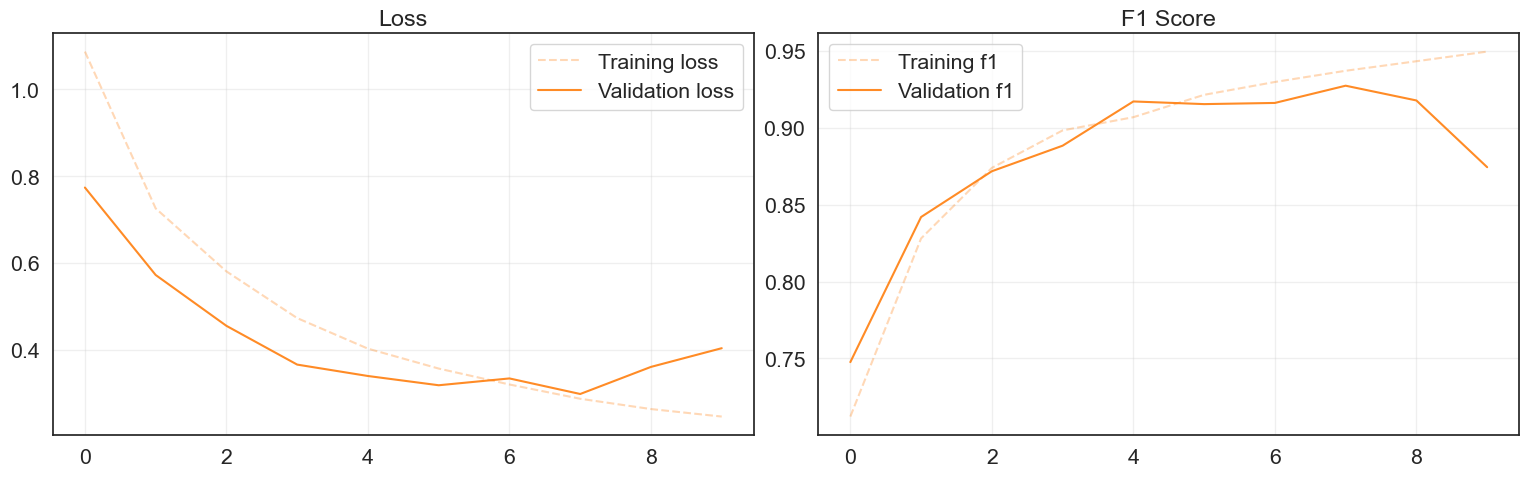

In [ ]:
# @title Plot Hitory
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

### Plot Confusion Matrix

Accuracy over the validation set: 0.1429
Precision over the validation set: 0.0204
Recall over the validation set: 0.1429
F1 score over the validation set: 0.0357


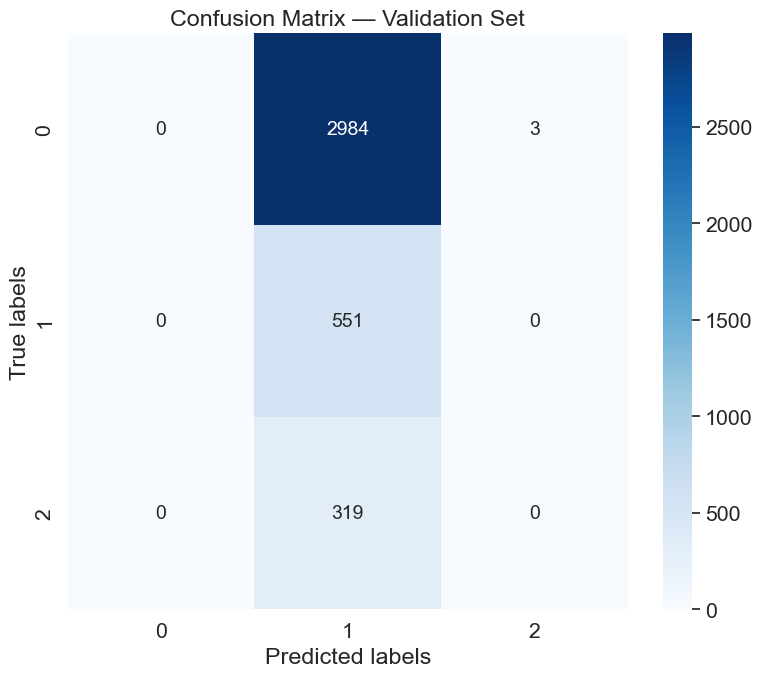

In [ ]:
# @title Plot Confusion Matrix
# Collect predictions and ground truth labels
val_preds, val_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb in val_loader:
        xb = xb.to(device)

        # Forward pass: get model predictions
        logits = rnn_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

## Make predictions on public test

In [ ]:
from datetime import datetime

# --- 1. Re-use your build_sequences function from Cell 20 ---
# (Make sure 'feature_cols' is defined as it was in Cell 19)
# (Make sure WINDOW_SIZE=40 and STRIDE=10 are defined as in Cell 18)

# This function is needed to process the test data
def build_test_sequences(df, window, stride):
    X_test_sequences = []
    sample_indices = []
    
    # Group by sample_index
    for sid in df["sample_index"].unique():
        temp = df[df["sample_index"] == sid][feature_cols].values.astype("float32")
        
        # --- Padding section (same as training) ---
        remainder = len(temp) % window
        if remainder > 0:
            pad_len = window - remainder
            padding = np.zeros((pad_len, temp.shape[1]), dtype="float32")
            temp = np.concatenate((temp, padding), axis=0)

        # --- Sliding window (same as training) ---
        idx = 0
        sequences_for_this_sample = []
        while idx + window <= len(temp):
            sequences_for_this_sample.append(temp[idx:idx + window])
            idx += stride
            
        X_test_sequences.append(np.array(sequences_for_this_sample))
        sample_indices.append(sid)

    return X_test_sequences, sample_indices

# --- 2. Build the test sequences ---
# This will result in a list of arrays, e.g., (113 users, 13 windows, 40 timesteps, 34 features)
test_sequences, test_sample_indices = build_test_sequences(df_public_test, WINDOW_SIZE, STRIDE)

# --- 3. Make predictions window-by-window and aggregate ---
best_model.eval()
final_predictions = []

with torch.no_grad():
    for user_sequences in test_sequences:
        # Convert this user's 13 sequences to a tensor
        user_tensor = torch.tensor(user_sequences, dtype=torch.float32).to(device)
        
        # Get logits for all 13 windows at once
        # Shape: (13, 3)
        logits = best_model(user_tensor)
        
        # Convert to probabilities using softmax
        # Shape: (13, 3)
        probabilities = torch.nn.functional.softmax(logits, dim=1)
        
        # Average the probabilities across all 13 windows
        # Shape: (3)
        mean_probs = torch.mean(probabilities, dim=0)
        
        # Get the final class prediction for this user
        pred_class = torch.argmax(mean_probs).item()
        final_predictions.append(pred_class)

# --- 4. Map back to original labels ---
inverse_label_mapping = {v: k for k, v in label_mapping.items()}
predicted_labels = [inverse_label_mapping[p] for p in final_predictions]

# --- 5. Save submission ---
submission_df = pd.DataFrame({
    "sample_index": test_sample_indices,
    "label": predicted_labels
})

submission_filename = f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_submission.csv"
submission_df.to_csv(submission_filename, index=False)
print(f"{submission_filename} created successfully!")
print(submission_df.head())

AttributeError: 'NoneType' object has no attribute 'eval'